## **Klasifikasi Sampah Bertingkat Menggunakan Pendekatan Hierarchical dengan Vision Transformer pada Level Super-Class dan MobileNetV3 serta ConvNeXt-Tiny pada Sub-Class**

## **Latar Belakang**

Pengelolaan sampah merupakan salah satu tantangan utama dalam menjaga kelestarian lingkungan. Seiring dengan meningkatnya jumlah penduduk dan aktivitas manusia, volume sampah yang dihasilkan terus bertambah sehingga proses pemilahan sampah secara manual menjadi kurang efisien, membutuhkan waktu yang lama, serta rentan terhadap kesalahan manusia (*human error*). Kondisi tersebut menyebabkan proses daur ulang menjadi kurang optimal karena banyak sampah yang tidak dipisahkan sesuai dengan jenisnya.

Perkembangan teknologi **Artificial Intelligence (AI)**, khususnya **Deep Learning**, memberikan solusi dalam proses klasifikasi citra secara otomatis. Berbagai penelitian menunjukkan bahwa model Deep Learning mampu mengenali objek berdasarkan karakteristik visual seperti bentuk, warna, tekstur, dan pola dengan tingkat akurasi yang tinggi. Oleh karena itu, teknologi ini dapat dimanfaatkan untuk membantu proses klasifikasi sampah secara otomatis sehingga mendukung sistem pengelolaan sampah yang lebih cepat, akurat, dan efisien.

Pada penelitian ini dikembangkan sistem klasifikasi sampah menggunakan pendekatan **Hierarchical Classification**. Pendekatan ini membagi proses klasifikasi menjadi dua tahap. Tahap pertama menggunakan **Vision Transformer (ViT-B/16)** untuk mengklasifikasikan sampah menjadi dua kategori utama, yaitu **Organik** dan **Anorganik**. Selanjutnya, hasil klasifikasi tersebut diteruskan ke model khusus, yaitu **MobileNetV3** untuk klasifikasi sampah organik dan **ConvNeXt-Tiny** untuk klasifikasi sampah anorganik. Pendekatan bertingkat ini diharapkan mampu meningkatkan akurasi klasifikasi karena setiap model hanya berfokus pada kategori yang lebih spesifik.

## **Tujuan Penelitian**

Penelitian ini bertujuan untuk membangun sistem klasifikasi sampah berbasis Deep Learning menggunakan pendekatan **Hierarchical Classification**. Sistem yang dikembangkan diharapkan mampu mengklasifikasikan jenis sampah secara otomatis berdasarkan citra dengan tingkat akurasi yang tinggi.

Secara khusus, penelitian ini memiliki beberapa tujuan, yaitu:

1. Membangun model klasifikasi awal menggunakan **Vision Transformer (ViT-B/16)** untuk membedakan sampah organik dan anorganik.
2. Mengembangkan model **MobileNetV3** untuk melakukan klasifikasi lebih lanjut pada kategori sampah organik.
3. Mengembangkan model **ConvNeXt-Tiny** untuk melakukan klasifikasi lebih lanjut pada kategori sampah anorganik.
4. Mengevaluasi performa setiap model menggunakan metrik Accuracy, Precision, Recall, dan F1-Score.
5. Mengimplementasikan sistem klasifikasi bertingkat sehingga proses identifikasi jenis sampah menjadi lebih akurat dan efisien.

## **Alur Program**

Sistem klasifikasi sampah pada penelitian ini terdiri dari beberapa tahapan utama yang saling berkaitan.

1. **Exploratory Data Analysis (EDA)** dilakukan untuk menganalisis karakteristik dataset, distribusi kelas, jumlah data, serta kualitas citra yang digunakan.
2. **Dataset Processing** dilakukan dengan membagi dataset menjadi data training, validation, dan testing, kemudian menyusun struktur folder yang sesuai untuk proses pelatihan model.
3. **Training Root Model** menggunakan arsitektur **Vision Transformer (ViT-B/16)** untuk mengklasifikasikan gambar ke dalam dua kategori utama, yaitu Organik dan Anorganik.
4. **Training Sub Model** dilakukan menggunakan dua model berbeda, yaitu **MobileNetV3** untuk klasifikasi sampah organik dan **ConvNeXt-Tiny** untuk klasifikasi sampah anorganik.
5. **Inference** dilakukan dengan menerapkan pendekatan hierarchical classification. Setiap gambar terlebih dahulu diprediksi menggunakan Vision Transformer. Jika hasil prediksi menunjukkan kategori Organik, maka gambar diproses menggunakan MobileNetV3. Sebaliknya, jika termasuk kategori Anorganik, gambar diproses menggunakan ConvNeXt-Tiny hingga diperoleh hasil klasifikasi akhir.
6. **Evaluasi Model** dilakukan menggunakan Confusion Matrix, Accuracy, Precision, Recall, dan F1-Score untuk mengukur performa sistem secara keseluruhan.
```mermaid
flowchart TD

A([Start])
-->B[Load Dataset]

B-->C[EDA]

C-->D[Dataset Processing]

D-->E[Train Root Model<br/>ViT-B/16]

E-->F[Save Root Model]

F-->G[Train Organic Model<br/>MobileNetV3]

G-->H[Save Organic Model]

H-->I[Train Inorganic Model<br/>ConvNeXt-Tiny]

I-->J[Save Inorganic Model]

J-->K[Inference]

K-->L{Root Prediction}

L-- Organic -->M[MobileNetV3]

L-- Inorganic -->N[ConvNeXt-Tiny]

M-->O[Final Classification]

N-->O

O-->P[Evaluation]

P-->Q[Confusion Matrix]

Q-->R[Accuracy]

R-->S[Precision]

S-->T[Recall]

T-->U[F1-Score]

U-->V([Finish])
```

## **Import Library**

In [22]:
import os
import glob
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pandas as pd

# Buat Atasi Warning
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)

# atur tema visualisasi kita
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.figsize'] = (10, 6)

# input data
RAW_DATA_DIR = "../data/raw"
print(f"data berhasil di input dari {RAW_DATA_DIR}")

data berhasil di input dari ../data/raw


# **Baca Dataset dan Buat Data Frame**


### Tujuan

Cell ini bertujuan untuk membaca seluruh gambar pada dataset, kemudian menyusun informasi penting seperti lokasi file dan label kelas ke dalam sebuah **DataFrame** sehingga data lebih mudah dianalisis.

### Proses

Setiap folder pada dataset dianggap sebagai satu kelas. Selanjutnya program melakukan pencarian seluruh file gambar, kemudian menyimpan informasi berupa:

- Path gambar.
- Nama kelas (label).
- Nama file.

Informasi tersebut kemudian disimpan ke dalam **DataFrame** menggunakan library Pandas.

Secara konseptual, DataFrame dapat direpresentasikan sebagai

\[
D=
\begin{bmatrix}
Path_1 & Label_1\\
Path_2 & Label_2\\
\vdots & \vdots\\
Path_N & Label_N
\end{bmatrix}
\]

dengan:

- \(N\) = jumlah seluruh gambar.

### Implementasi

Output dari proses ini adalah sebuah DataFrame yang berisi informasi seluruh gambar pada dataset. DataFrame tersebut akan digunakan pada seluruh proses analisis berikutnya.

In [14]:
image_paths = []
Labels = []

extensions = ['*.jpg', '*.jpeg', '*.png']

for ext in extensions:
    search_path = os.path.join(RAW_DATA_DIR, "**", ext)
    for path in glob.glob(search_path, recursive=True):
        image_paths.append(path)
        Labels.append(os.path.basename(os.path.dirname(path)))

df_eda = pd.DataFrame({
    'image_path': image_paths,
    'Label': Labels
})

print(f"Jumlah keseluruhan data: {len(df_eda)}")
print("\nContoh data teratas:")
display(df_eda.head())

Jumlah keseluruhan data: 4741

Contoh data teratas:


,image_path,Label
0,../data/raw\Cardboard\Cardboard_109.jpg,Cardboard
1,../data/raw\Cardboard\Cardboard_11.jpg,Cardboard
2,../data/raw\Cardboard\Cardboard_110.jpg,Cardboard
3,../data/raw\Cardboard\Cardboard_111.jpg,Cardboard
4,../data/raw\Cardboard\Cardboard_112.jpg,Cardboard


# **Distribusi Data per Kelas**


### Tujuan

Cell ini digunakan untuk mengetahui jumlah gambar pada setiap kelas sehingga dapat diketahui apakah dataset memiliki distribusi yang seimbang (**balanced**) atau tidak (**imbalanced**).

### Proses

Jumlah data setiap kelas dihitung menggunakan fungsi

```python
value_counts()
```

Kemudian persentase masing-masing kelas dihitung menggunakan persamaan

$$
P_i=
\frac{n_i}{N}
\times100\%
$$

dengan:

- \(P_i\) = persentase kelas ke-i
- \(n_i\) = jumlah gambar pada kelas ke-i
- \(N\) = jumlah seluruh gambar

Distribusi kelas kemudian divisualisasikan menggunakan diagram batang (bar chart).

### Implementasi

Apabila terdapat perbedaan jumlah data yang cukup besar antar kelas, maka dataset dikatakan mengalami **data imbalance**. Informasi ini menjadi dasar penggunaan **class weights** pada proses pelatihan model.

,Kelas,Jumlah Gambar
0,Plastic,921
1,Metal,790
2,Paper,500
3,Miscellaneous Trash,495
4,Cardboard,450
5,Vegetation,436
6,Glass,420
7,Food Organics,411
8,Textile Trash,318


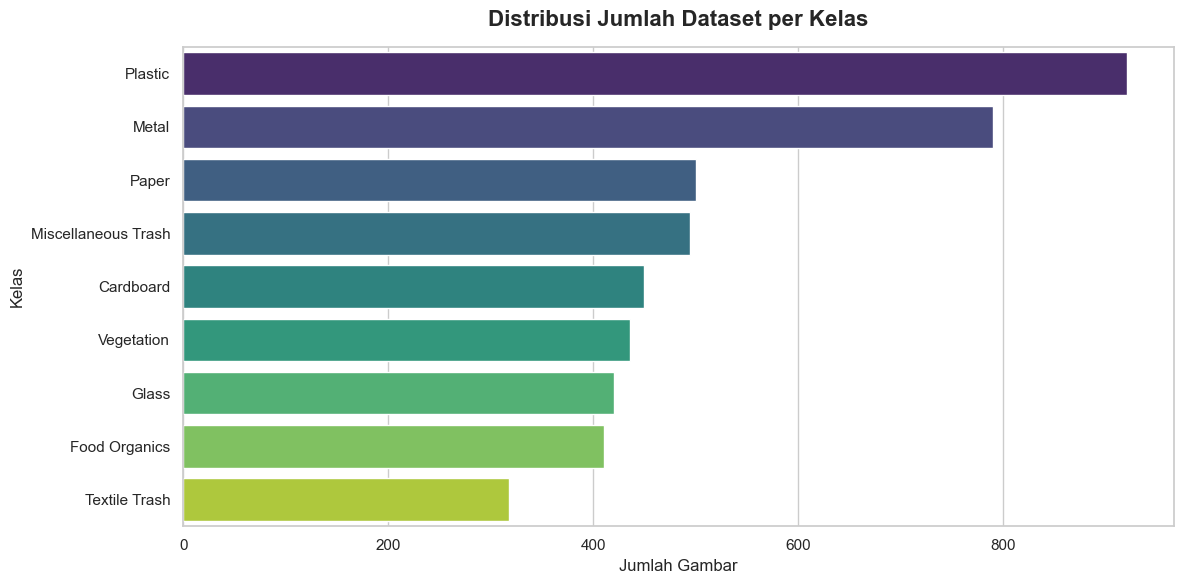

In [ ]:
class_counts = df_eda['Label'].value_counts().reset_index()
class_counts.columns = ['Kelas', 'Jumlah Gambar']
display(class_counts)

# Visualisasi distribusi Kelas
plt.figure(figsize=(12, 6))
sns.barplot(data=class_counts, x='Jumlah Gambar', y='Kelas', palette='viridis')
plt.title("Distribusi Jumlah Dataset per Kelas", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Jumlah Gambar", fontsize=12)
plt.ylabel("Kelas", fontsize=12)
plt.tight_layout()

os.makedirs("../reports/eda", exist_ok=True)
plt.savefig("../reports/eda/distribusi_kelas.png", dpi=300)
plt.show()

# **Analisis Dimensi Gambar**


### Tujuan

Cell ini bertujuan untuk mengetahui ukuran (dimensi) setiap gambar pada dataset sehingga dapat dipastikan apakah seluruh gambar memiliki ukuran yang seragam atau memerlukan proses resize sebelum pelatihan model.

### Proses

Setiap gambar dibaca menggunakan library **PIL**, kemudian diambil informasi berupa:

- Lebar gambar (Width)
- Tinggi gambar (Height)

Ukuran gambar dinyatakan sebagai

\[
Dimensi=(W,H)
\]

dengan:

- \(W\) = lebar gambar (pixel)
- \(H\) = tinggi gambar (pixel)

Selanjutnya dilakukan visualisasi distribusi ukuran gambar menggunakan histogram atau grafik distribusi.

### Implementasi

Hasil analisis dimensi digunakan untuk menentukan ukuran input model. Pada penelitian ini seluruh gambar nantinya diubah menjadi ukuran **224 × 224 piksel** agar sesuai dengan kebutuhan model Vision Transformer (ViT-B/16).

In [27]:
widths = []
heights = []

print("Menghitung dimensi gambar...")
for path in df_eda['image_path']:
    with Image.open(path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

df_eda['width'] = widths
df_eda['height'] = heights
df_eda['aspect_ratio'] = df_eda['width'] / df_eda['height']

print("\nRingkasan Dimensi Gambar:")
display(df_eda[['width', 'height', 'aspect_ratio']].describe())


Menghitung dimensi gambar...

Ringkasan Dimensi Gambar:


,width,height,aspect_ratio
count,4741.0,4741.0,4741.0
mean,524.0,524.0,1.0
std,0.0,0.0,0.0
min,524.0,524.0,1.0
25%,524.0,524.0,1.0
50%,524.0,524.0,1.0
75%,524.0,524.0,1.0
max,524.0,524.0,1.0


# **Cek Gambar Rusak**


### Tujuan

Cell ini digunakan untuk mendeteksi gambar yang rusak (**corrupted image**) sehingga tidak menyebabkan kesalahan ketika proses pelatihan model berlangsung.

### Proses

Program mencoba membuka setiap file gambar menggunakan library **PIL**. Apabila gambar tidak dapat dibaca atau terjadi error, maka path gambar tersebut dimasukkan ke dalam daftar gambar rusak.

Secara konseptual,

$$
Status=
\begin{cases}
Valid,&\text{gambar dapat dibaca}\\
Corrupt,&\text{gambar tidak dapat dibaca}
\end{cases}
$$

Jumlah gambar rusak dihitung menggunakan

$$
Total_{corrupt}
=
\sum_{i=1}^{N}I_i
$$

dengan:

- \(I_i=1\) jika gambar rusak.
- \(I_i=0\) jika gambar valid.

### Implementasi

Apabila ditemukan gambar yang rusak, gambar tersebut sebaiknya dihapus atau diganti sebelum proses pelatihan model agar tidak menyebabkan error saat DataLoader membaca dataset.

In [29]:
corrupted_files =[]

for path in df_eda['image_path']:
    try:
        with Image.open(path) as img:
            img.verify()
    except (IOError, SyntaxError) as e:
        print(f"Tidak Ada gambar yang ditemukan: {path}")
        corrupted_files.append(path)

if len(corrupted_files) == 0:
    print("Tidak Ada Gambar yg Rusak")
else:
    print(f"Jumlah Data Rusak: {len(corrupted_files)}Gambar Rusak")

Tidak Ada Gambar yg Rusak


# **Sampel Gambar per Kelas**


### Tujuan

Cell ini bertujuan untuk menampilkan beberapa contoh gambar dari setiap kelas sehingga karakteristik visual masing-masing kelas dapat diamati secara langsung.

### Proses

Program memilih beberapa gambar secara representatif dari setiap kelas, kemudian menampilkannya menggunakan **Matplotlib**. Visualisasi ini membantu memverifikasi bahwa label telah sesuai dengan isi gambar serta memberikan gambaran mengenai variasi bentuk, warna, tekstur, dan kualitas citra pada setiap kelas.

### Implementasi

Hasil visualisasi digunakan sebagai validasi awal terhadap dataset sebelum memasuki tahap preprocessing dan pelatihan model. Dengan meninjau sampel gambar, peneliti dapat memastikan bahwa struktur dataset sudah benar dan tidak terdapat kesalahan pelabelan yang mencolok.

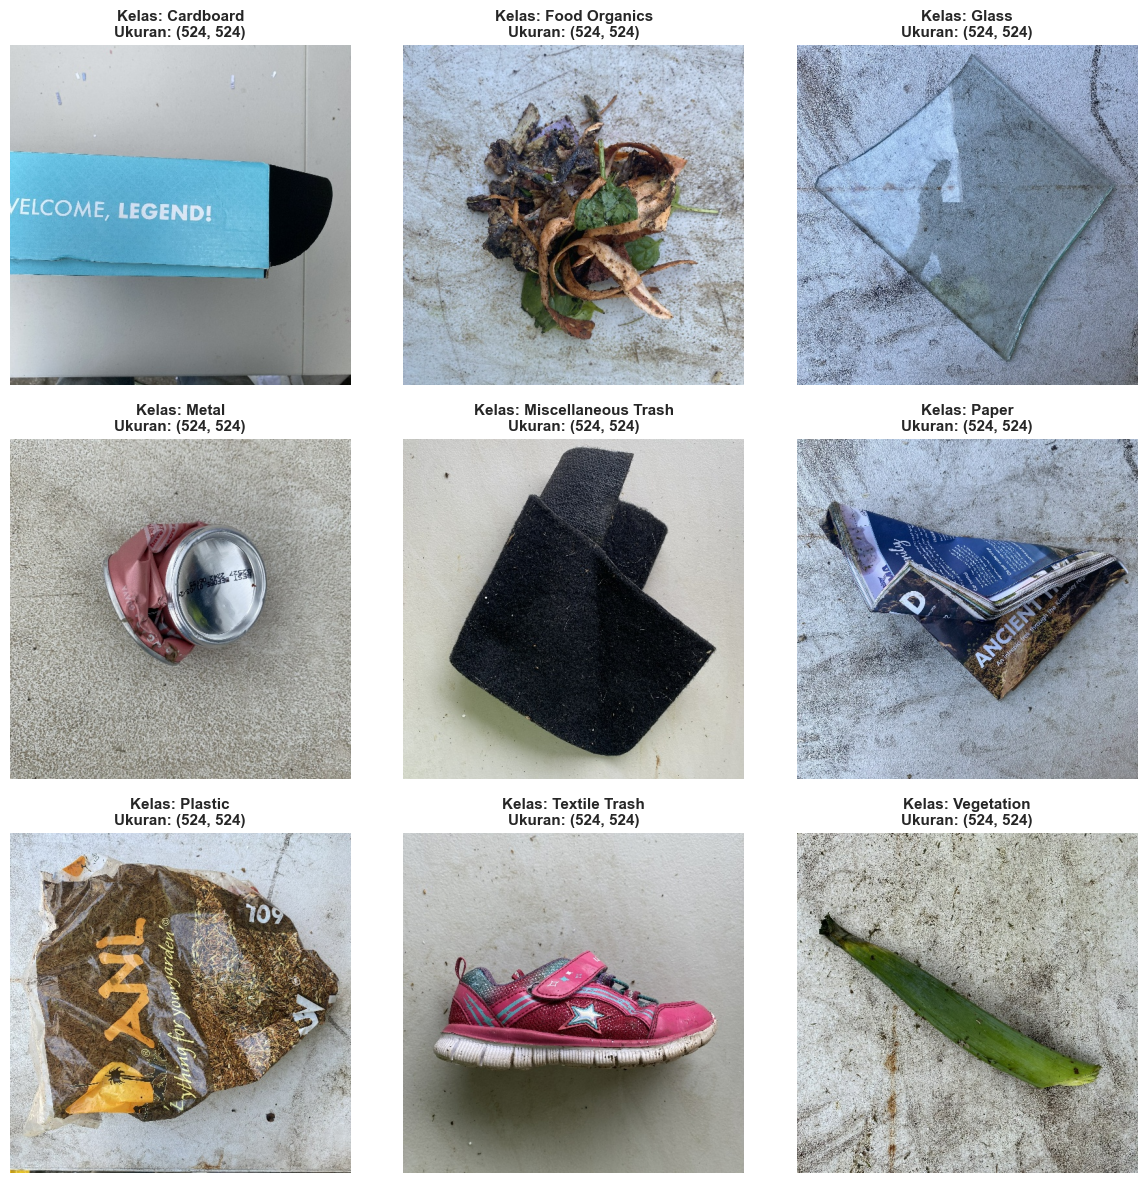

In [ ]:
unique_classes = df_eda['Label'].unique()
num_classes = len(unique_classes)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i, cls in enumerate(sorted(unique_classes)):
    # Ambil 1 sampel acak dari kelas terkait
    sample_path = df_eda[df_eda['Label'] == cls]['image_path'].sample(1, random_state=42).values[0]
    
    with Image.open(sample_path) as img:
        axes[i].imshow(img)
        axes[i].set_title(f"Kelas: {cls}\nUkuran: {img.size}", fontsize=11, fontweight='bold')
        axes[i].axis('off')

# Matikan sisa axes jika kelas kurang dari jumlah grid
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig("../reports/figures/02_visualisasi_sampel_kelas.png", dpi=300)
plt.show()